In [5]:
import matplotlib.pyplot as plt
import numpy as np
import json
from matplotlib.lines import Line2D

log_dirs = {
    r'$\mathrm{PDA}^2(\mathrm{Adam})$': "/home/xinyanhan/ADC/adc_nips/logs/accident_NC_TX_pda_adam_score_0_25",
    r"$\mathrm{PDA}^2(\mathrm{SGD})$": "/home/xinyanhan/ADC/adc_nips/logs/accident_NC_TX_pda_sgd_score_0_25",
    r"uniform": "/home/xinyanhan/ADC/adc_nips/logs/accident_NC_TX_uniform_[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]",
    r'DAA': "/home/xinyanhan/ADC/adc_nips/logs/accident_NC_TX_daa_[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]",
    r'oracle': "/home/xinyanhan/ADC/adc_nips/logs/accident_NC_TX_oracle_[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]",
    r'50Target': "/home/xinyanhan/ADC/adc_nips/logs/accident_NC_TX_val_[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]"
}
output_path = "/home/xinyanhan/ADC/adc_nips/plot/accident_NC_TX.pdf"
# colors = {
#     r'$\mathrm{PDA}^2(\mathrm{Adam})$': '#933d29',
#     r"$\mathrm{PDA}^2(\mathrm{SGD})$": '#d88d6d',
#     r"uniform": '#48b4a7',
#     r"DAA": '#655f78',
#     r"oracle": '#a48f76',
#     r"original": "#372e37"
# }
# colors = {
#     r'$\mathrm{PDA}^2(\mathrm{Adam})$': '#bc3742',
#     r"$\mathrm{PDA}^2(\mathrm{SGD})$": '#457097',
#     r"uniform": '#848e3f',
#     r"DAA": '#102056',
#     r"oracle": '#e2a2a7',
#     r"original": "#372e37"
# }
colors = {
    r'$\mathrm{PDA}^2(\mathrm{Adam})$': '#a93c75',
    r"$\mathrm{PDA}^2(\mathrm{SGD})$": '#5088aa',
    r"uniform": '#d8ac46',
    r"DAA": '#e8d32b',
    r"oracle": '#88b5d6',
    r"original": "#372e37",
    r"50Target": "#794651"
}
markers = {
    r'$\mathrm{PDA}^2(\mathrm{Adam})$': 'o',
    r"$\mathrm{PDA}^2(\mathrm{SGD})$": 's',
    r"uniform": 'v',
    r"DAA": '^',
    r"oracle": 'D',
    r'50Target': 'X',
}

yticks = [0.7, 0.8,0.9]
ylim = [0.65, 0.92]

mean_value = {}
std = {}
xticks = []
axhlines = {}
for k, v in log_dirs.items():
    if k == r"50Target":
        continue
    f = open(v + "/summary.json")
    summary = json.load(f)
    mean_value[k] = np.array(summary['test_acc']).mean(axis=0)
    std[k] = np.array(summary['test_acc']).std(axis=0) / np.sqrt(len(summary['test_acc'])) * 1.96
    xticks = summary['n_samples_used']
    axhlines[r"original"] = np.array([acc[0] for acc in summary['test_acc']]).mean(axis=0)

if r"50Target" in log_dirs:
    f = open(log_dirs[r'50Target'] + "/summary.json")
    test_acc = json.load(f)['test_acc']
    test_acc = [acc[0] for acc in test_acc]
    axhlines[r"50Target"] = np.array(test_acc).mean(axis=0)


[0, 128, 256, 384]
[0.7067829  0.81606222 0.86525438 0.86397836]
[0, 128, 256, 384]
[0.7067829  0.77166905 0.79450214 0.80603742]
[0, 128, 256, 384]
[0.7067829  0.7028857  0.70745923 0.70865409]
[0, 128, 256, 384]
[0.7067829  0.69753062 0.69664988 0.70401894]
[0, 128, 256, 384]
[0.7067829  0.8289126  0.89924701 0.90362366]


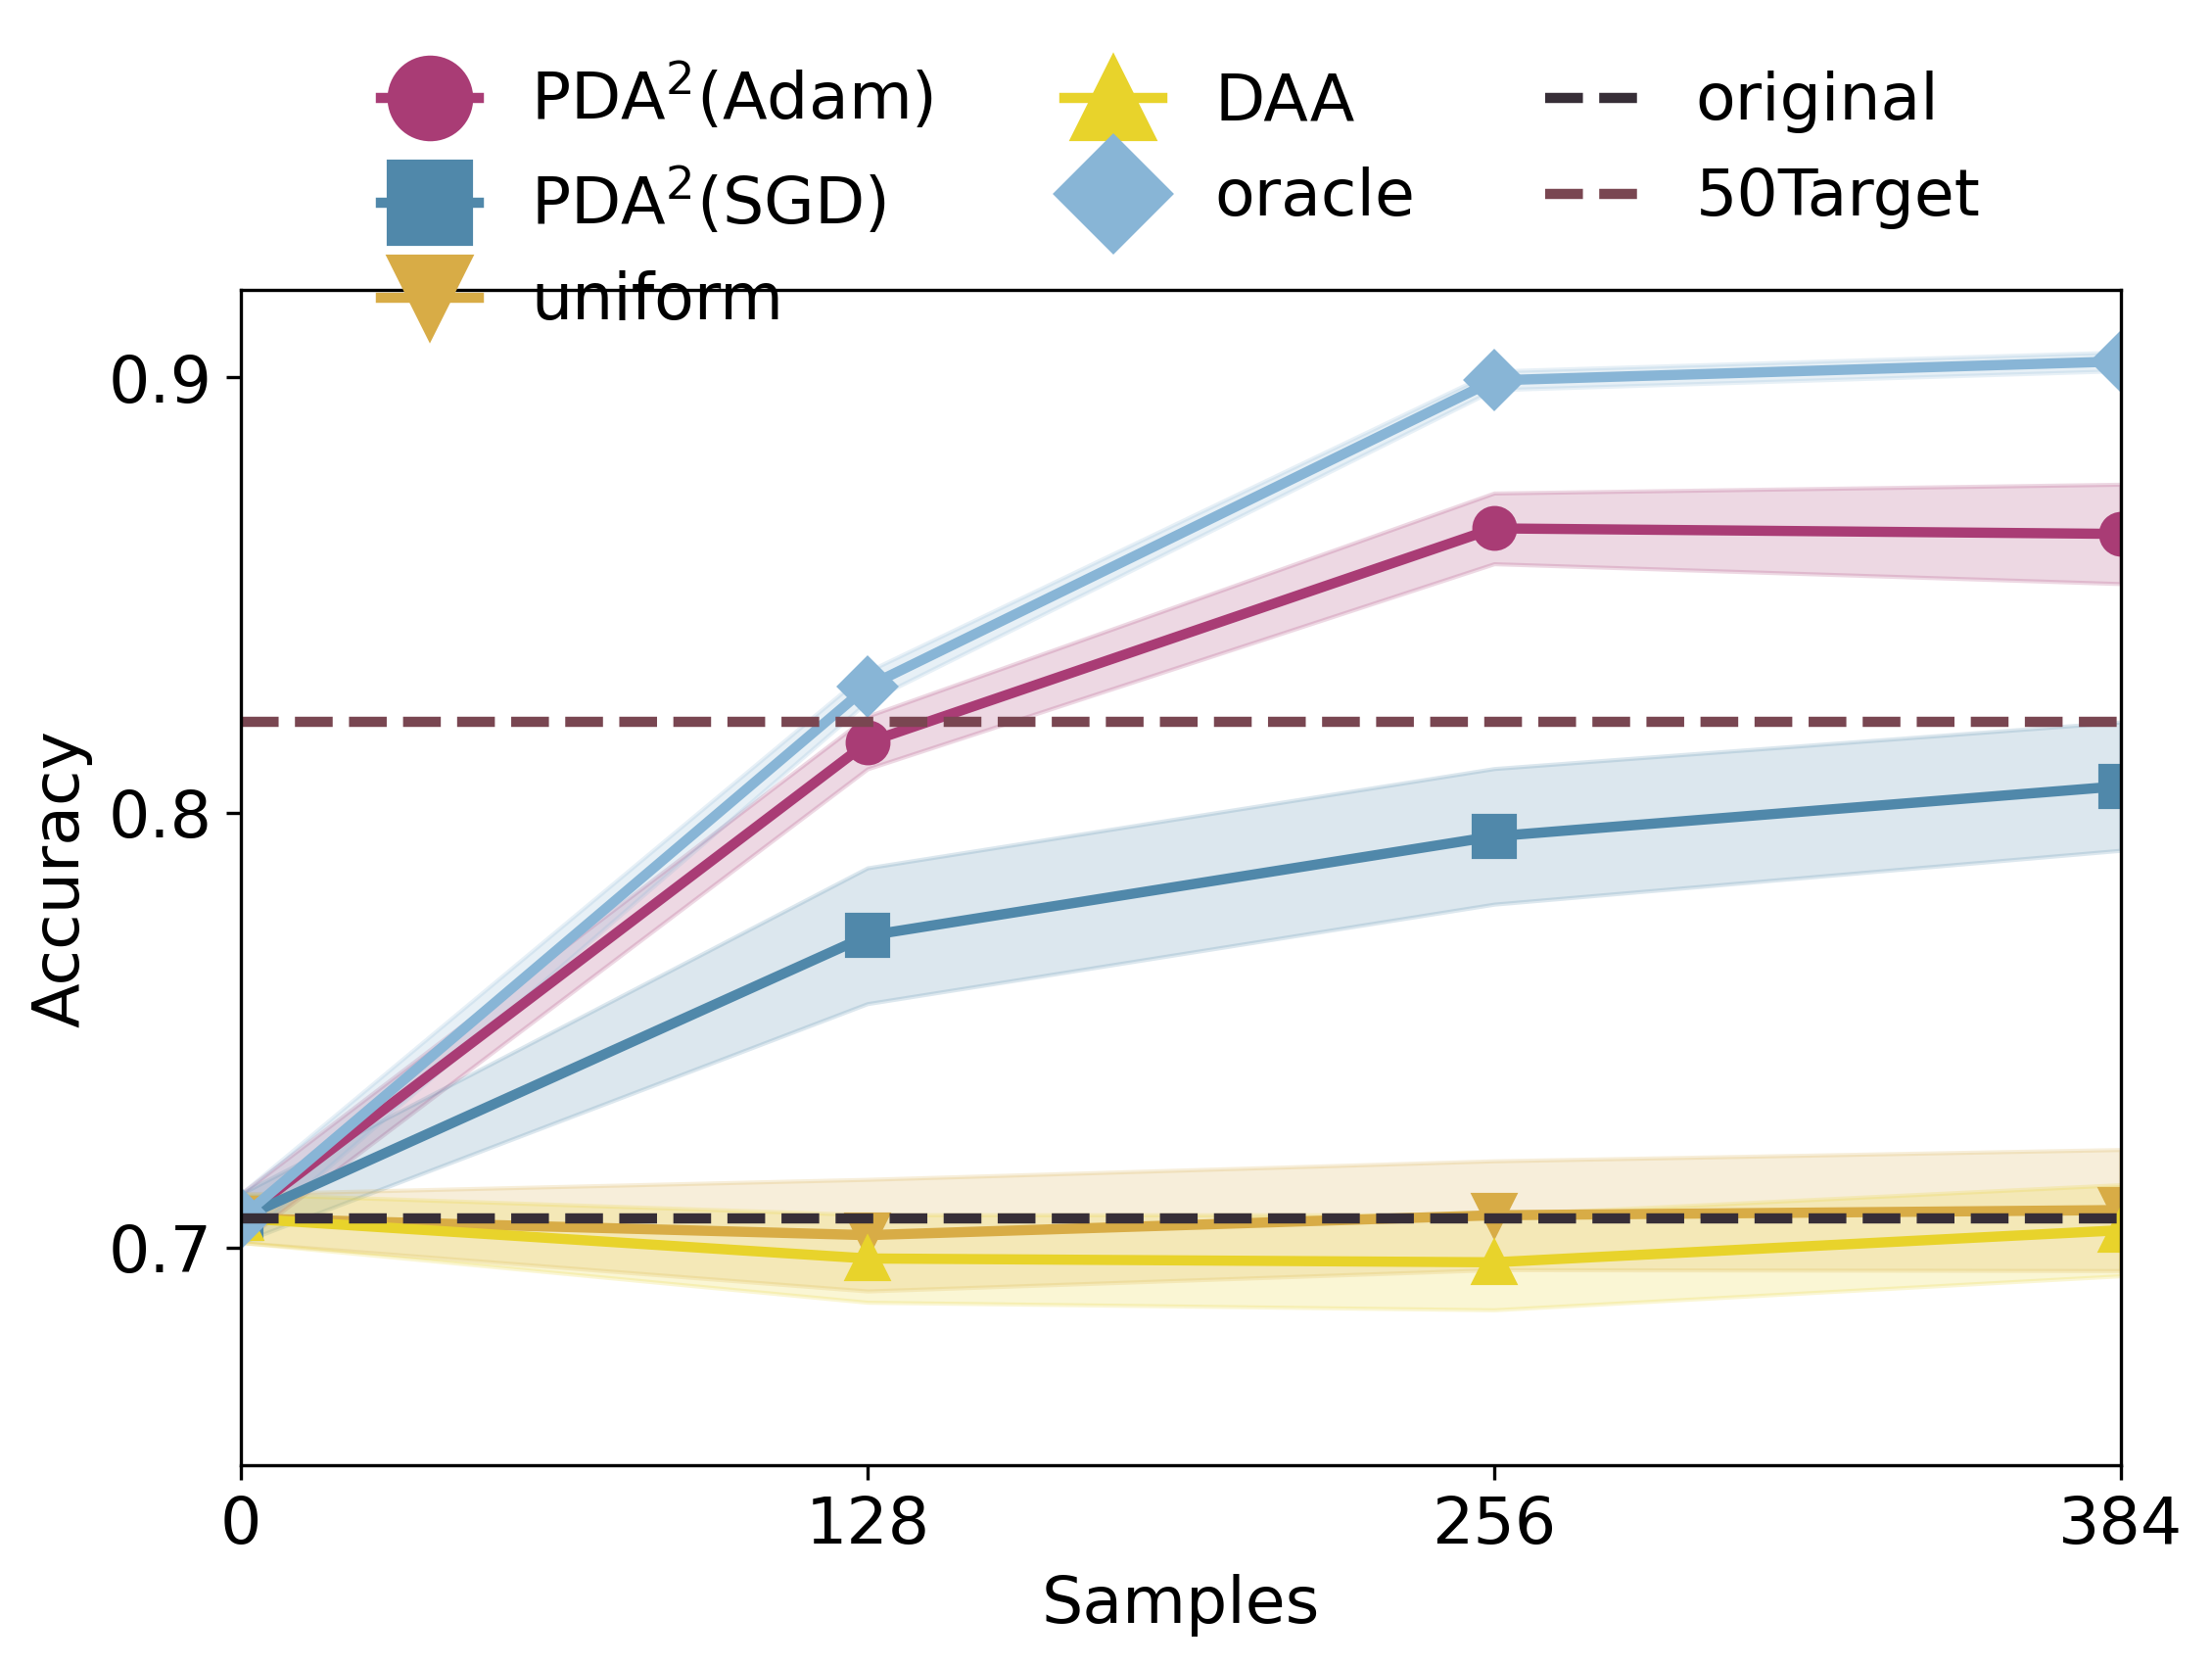

In [6]:
plt.figure(dpi=300, figsize=(8, 5))
for k, v in mean_value.items():
    print(xticks)
    print(v)
    plt.plot(xticks, v, label=k, color=colors[k], linewidth=2.5, marker=markers[k], markersize=10)
    plt.fill_between(xticks, np.array(v) - std[k], np.array(v) + std[k], alpha=0.2, color=colors[k])
for k, v in axhlines.items():
    plt.axhline(y=v, color=colors[k], linestyle='--', linewidth=2.5, label=k)
    
plt.xticks(xticks, fontsize=16)
plt.yticks(yticks, fontsize=16)
plt.xlabel("Samples", fontsize=16)
plt.ylabel("Accuracy", fontsize=16)
plt.ylim(ylim)
plt.xlim(xticks[0], xticks[-1])
plt.legend(
    fontsize=16,
    loc='upper center',              # 放在上方中间
    bbox_to_anchor=(0.5, 1.25),      # x轴中点 (0.5)，y轴稍高于顶部（1.15 可微调）
    frameon=False,
    handlelength=1.5,
    handleheight=0.5,
    borderpad=0.5,
    labelspacing=0.5,
    markerscale=2,
    ncol=3  # 可选：如果有多个 legend 项，设成多列
)
plt.tight_layout()
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)
plt.savefig(output_path, bbox_inches='tight',pad_inches=0)